In [1]:
import os
import pandas as pd
from skimage.feature import hog
from skimage.color import rgb2gray, rgb2hsv
from skimage.transform import resize
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from PIL import Image
import numpy as np
import tqdm
import tensorflow as tf
from tensorflow.keras import layers, models


2026-05-16 03:34:50.080177: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-16 03:34:50.098282: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Create dataframes from dataset files


#DATA_DIR = "CUB_200_2011"
DATA_DIR = "CUB_200_2011"
IMAGES_DIR = os.path.join(DATA_DIR, "images")

# Load the metadata files
images_df = pd.read_csv(
    os.path.join(DATA_DIR, "images.txt"),
    sep=" ",
    names=["image_id", "image_path"]
)

labels_df = pd.read_csv(
    os.path.join(DATA_DIR, "image_class_labels.txt"),
    sep=" ",
    names=["image_id", "class_id"]
)

bbox_df = pd.read_csv(
    os.path.join(DATA_DIR, "bounding_boxes.txt"),
    sep=" ",
    names=["image_id", "x", "y", "width", "height"]
)

splt_df = pd.read_csv(
    os.path.join(DATA_DIR, "train_test_split.txt"),
    sep=" ",
    names=["image_id", "is_train"]
)

# Merge all the dataframes into a single frame called 'data'
data = images_df.merge(labels_df, on="image_id").merge(bbox_df, on="image_id").merge(splt_df, on="image_id")

unique_classes = sorted(data["class_id"].unique())
print(f"Number of unique classes: {len(unique_classes)}")

class_mapping = {old: new for new, old in enumerate(unique_classes)}

data["label"] = data["class_id"].map(class_mapping)

data["full_path"] = data["image_path"].apply(
    lambda x: os.path.join(IMAGES_DIR, x)
)

# Split data into training and testing sets
train_df = data[data["is_train"] == 1].reset_index(drop=True)
test_df = data[data["is_train"] == 0].reset_index(drop=True)

train_paths = train_df["full_path"].values
train_labels = train_df["label"].values
train_bboxes = train_df[["x", "y", "width", "height"]].values

test_paths = test_df["full_path"].values
test_labels = test_df["label"].values
test_bboxes = test_df[["x", "y", "width", "height"]].values

print("Training samples:", len(train_df))
print("Testing samples:", len(test_df))
print("Number of classes:", data["label"].nunique())

# Calculate most common size size of images in the dataset
most_common_width = int(data["image_path"].apply(lambda x: Image.open(os.path.join(IMAGES_DIR, x)).size[0]).mode()[0])
most_common_height = int(data["image_path"].apply(lambda x: Image.open(os.path.join(IMAGES_DIR, x)).size[1]).mode()[0])
most_common_size = (most_common_width, most_common_height)
print(f"Most common image size: {most_common_size}")

# While the most common size is (500, 500), I run out of RAM, so we'll need to need to resize the images to a smaller size like (300, 300)
most_common_size = (160, 160)


# Resize the image to a fixed size for consistent feature extraction
def resizeImage(image, target_size):
    return resize(image, target_size)


Number of unique classes: 200
Training samples: 5994
Testing samples: 5794
Number of classes: 200
Most common image size: (500, 500)


In [3]:
# Extract 
def extract_hog(image):
    
    # Convert to grayscale (HOG works on intensity gradients)
    gray = rgb2gray(image)

    # Extract HOG features (edge/shape descriptors)
    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2)
    )
    return features

def extract_HSV_histogram(image):
    # Convert to HSV color space
    hsv = rgb2hsv(image)

    # Compute histograms for each channel
    h_hist, _ = np.histogram(hsv[:, :, 0], bins=50, range=(0, 1))
    s_hist, _ = np.histogram(hsv[:, :, 1], bins=50, range=(0, 1))
    v_hist, _ = np.histogram(hsv[:, :, 2], bins=50, range=(0, 1))

    # Concatenate histograms into a single feature vector
    histogram_features = np.concatenate([h_hist, s_hist, v_hist])
    return histogram_features

# This function builds the dataset (X, y)
def build_dataset(paths, labels, avg_size):
    X, y = [], []
    for p, l in tqdm.tqdm(zip(paths, labels), total=len(paths), desc="Building SVM dataset"):
        # Extract feature for each image
        image = Image.open(p).convert("RGB")
        image = np.array(image)
        image_data = resizeImage(image, avg_size)
        X.append(np.concatenate((
            extract_hog(image_data), 
            extract_HSV_histogram(image_data)
            )))
        y.append(l)
    return np.array(X), np.array(y)




# Build training and testing feature sets
X_train, y_train = build_dataset(train_paths, train_labels, avg_size=most_common_size)
X_test, y_test = build_dataset(test_paths, test_labels, avg_size=most_common_size)




Building SVM dataset: 100%|██████████| 5794/5794 [01:17<00:00, 74.93it/s]


In [4]:

# Apply PCA for dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize features (important for PCA)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply PCA - retain 95% of variance
pca = PCA(n_components=0.95)  # Keeps 95% of variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original features: {X_train.shape[1]}")
print(f"PCA components: {X_train_pca.shape[1]}")
print(f"Variance retained: {pca.explained_variance_ratio_.sum():.4f}")
print(f"Dimensionality reduction: {(1 - X_train_pca.shape[1] / X_train.shape[1]) * 100:.1f}%")

# Use PCA-reduced features for SVM
X_train = X_train_pca
X_test = X_test_pca


Original features: 13146
PCA components: 2474
Variance retained: 0.9500
Dimensionality reduction: 81.2%


In [6]:
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

svm = make_pipeline(
    StandardScaler(),
    OneVsRestClassifier(
        LinearSVC(
            C=1.0,
            max_iter=5000,               
            dual=False,                  
            verbose=1,
            random_state=42
        ),
        n_jobs=-1
    )
)

svm.fit(X_train, y_train)

[LibLinear][LibLinear][LibLinear][LibLinear]iter  1 act 5.939e+03 pre 5.927e+03 delta 9.964e-01 f 5.994e+03 |g| 1.192e+04 CG   1
iter  1 act 5.929e+03 pre 5.918e+03 delta 9.955e-01 f 5.994e+03 |g| 1.191e+04 CG   1
[LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear]iter  1 act 5.938e+03 pre 5.925e+03 delta 9.963e-01 f 5.994e+03 |g| 1.192e+04 CG   1
[LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear]iter  2 act 4.590e+01 pre 4.442e+01 delta 9.964e-01 f 5.501e+01 |g| 4.518e+02 CG   6
iter  1 act 5.935e+03 pre 5.923e+03 delta 9.961e-01 f 5.994e+03 |g| 1.192e+04 CG   1
iter  1 act 5.937e+03 pre 5.925e+03 delta 9.962e-01 f 5.994e+03 |g| 1.192e+04 CG   1
iter  2 act 5.101e+01 pre 4.959e+01 delta 9.955e-01 f 6.473e+01 |g| 4.412e+02 CG   7
iter  1 act 5.936e+03 pre 5.924e+03 delta 9.962e-01 f 5.994e+03 |g| 1.192e+04 CG   1
iter  1 act 5.940e+03 pre 5.928e+03 delta 9.965e-01 f 5.994e+03 |g| 1.192e+04 CG   1
[Lib

KeyboardInterrupt: 

In [ ]:
import joblib
joblib.dump(svm, "svm_model.joblib")

In [ ]:
# Evaluate SVM on test set
svm_accuracy = svm.score(X_test, y_test)
print(f"SVM Overall Accuracy: {svm_accuracy:.4f}")

# SVM class based accuracy
svm_predictions = svm.predict(X_test)
class_accuracies = {}
for cls in unique_classes:
    cls_indices = np.where(y_test == cls)[0]
    if len(cls_indices) == 0:
        print(f"SVM Accuracy for Class {cls}: no test samples")
        class_accuracies[cls] = np.nan
        continue
    cls_accuracy = np.mean(svm_predictions[cls_indices] == y_test[cls_indices])
    class_accuracies[cls] = cls_accuracy
    print(f"SVM Accuracy for Class {cls}: {cls_accuracy:.4f}")

# Optional: show how many test samples contributed to each class accuracy
print("\nTest samples per class:")
for cls in unique_classes:
    print(f"Class {cls}: {np.sum(y_test == cls)}")


SVM Overall Accuracy: 0.0190


KeyboardInterrupt: 

In [ ]:
# Create dataset for CNN
def build_cnn_dataset(paths, labels, avg_size):
    X, y = [], []
    for p, l in tqdm.tqdm(zip(paths, labels), total=len(paths), desc="Building CNN dataset"):
        image = Image.open(p).convert("RGB")
        image = np.array(image)
        image_data = resizeImage(image, avg_size)
        X.append(image_data)
        y.append(l)
    return np.array(X), np.array(y)
#X_train, y_train = build_cnn_dataset(train_paths, train_labels, avg_size=most_common_size)
#X_test, y_test = build_cnn_dataset(test_paths, test_labels, avg_size=most_common_size)

def build_boundingbox_cnn_dataset(paths, labels, bboxes, avg_size):
    X, y = [], []
    for p, l, bbox in tqdm.tqdm(zip(paths, labels, bboxes), total=len(paths), desc="Building Bounding Box CNN dataset"):
        image = Image.open(p).convert("RGB")
        image = np.array(image)
        
        # Extract bbox coordinates
        x, y_coord, width, height = bbox
        x, y_coord, width, height = int(x), int(y_coord), int(width), int(height)
        
        # Ensure bbox is within image bounds
        x = max(0, x)
        y_coord = max(0, y_coord)
        x_end = min(image.shape[1], x + width)
        y_end = min(image.shape[0], y_coord + height)
        
        # Crop to bounding box
        image_cropped = image[y_coord:y_end, x:x_end]
        
        # Resize the cropped image (resizeImage already outputs [0, 1], so no need to normalize again)
        image_data = resizeImage(image_cropped, avg_size)
        
        X.append(image_data)
        y.append(l)
    
    return np.array(X), np.array(y)

X_train, y_train = build_boundingbox_cnn_dataset(train_paths, train_labels, train_bboxes, avg_size=most_common_size)
X_test, y_test = build_boundingbox_cnn_dataset(test_paths, test_labels, test_bboxes, avg_size=most_common_size)

Building Bounding Box CNN dataset: 100%|██████████| 5794/5794 [00:28<00:00, 206.40it/s]


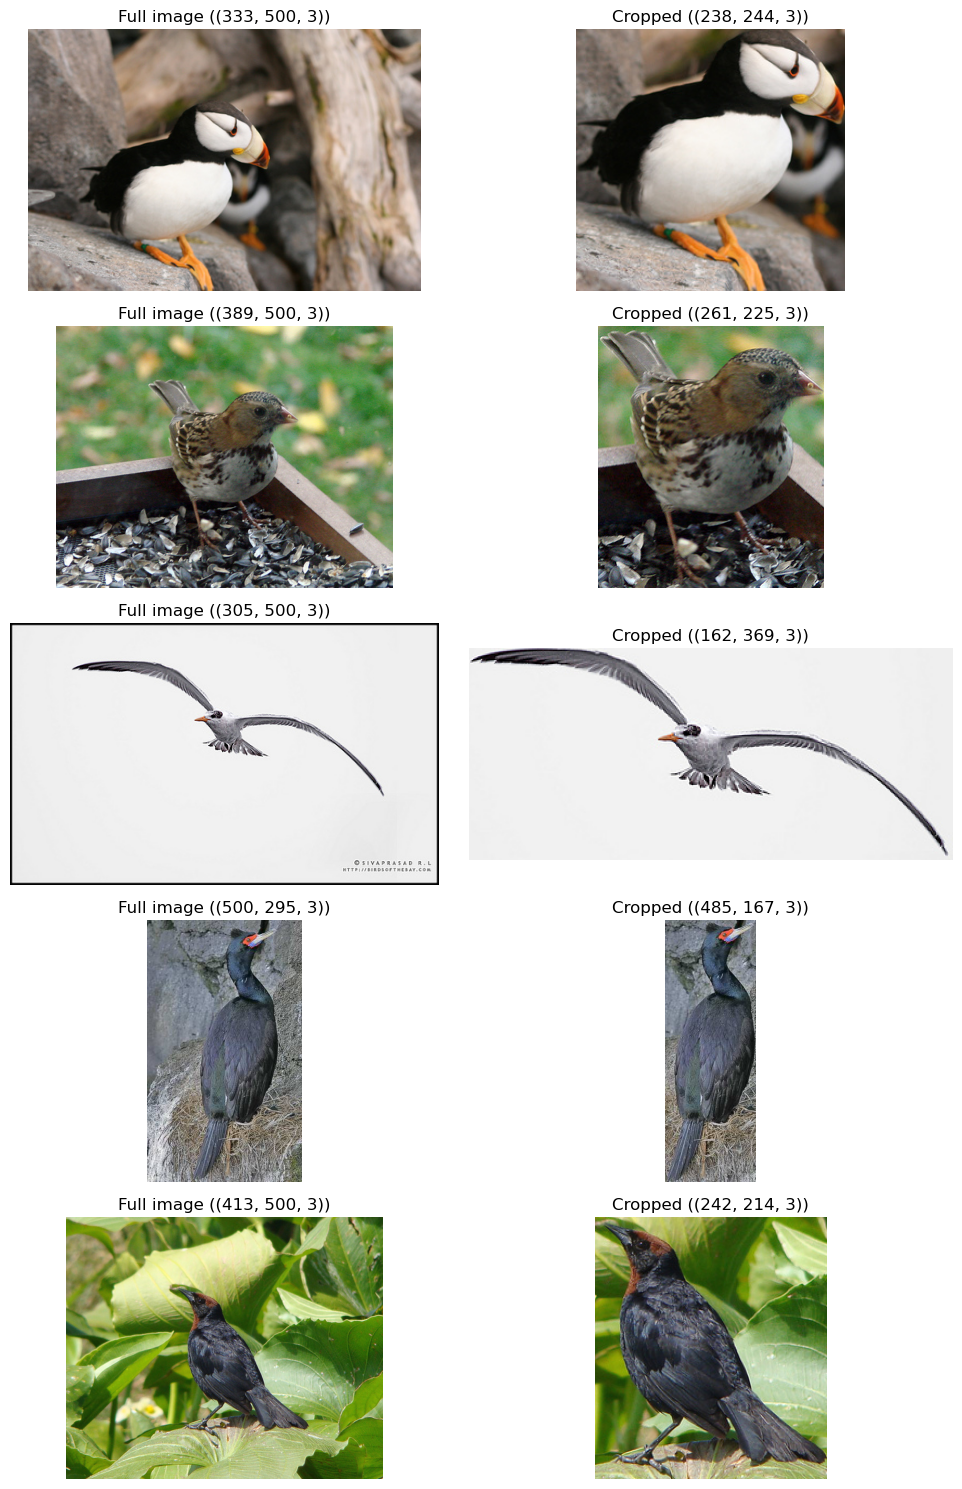

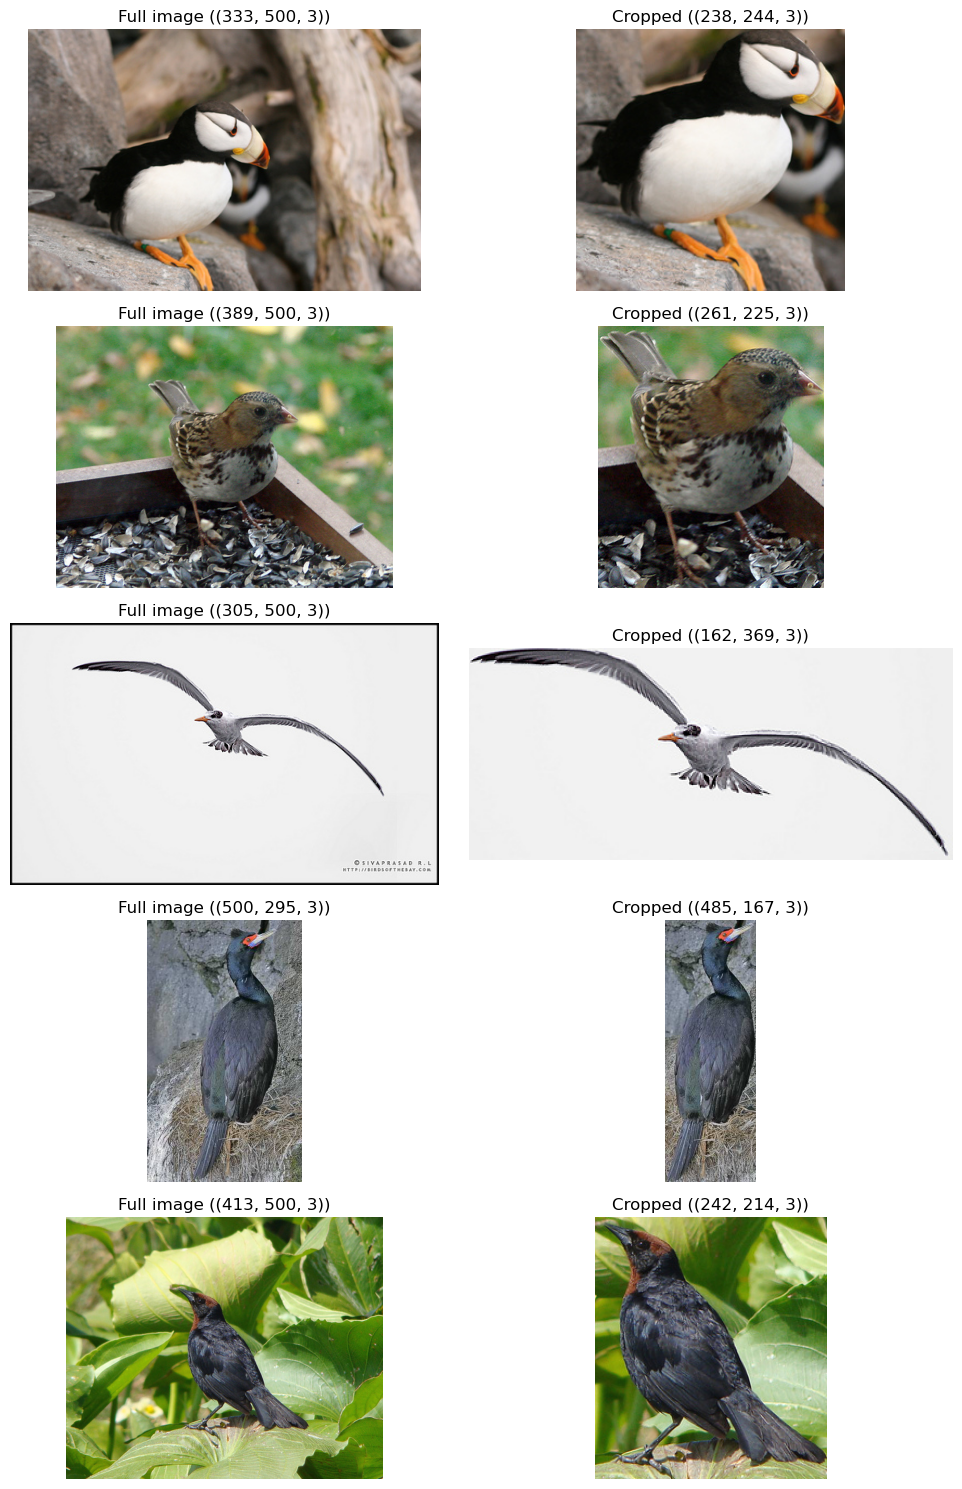


=== Bounding Box Statistics ===
Valid crops: 5
Empty crops: 0
Too small crops: 0

Total training samples: 5994

Dataset X_train stats:
Shape: (5994, 160, 160, 3)
Min value: 0.0000 (should be ~0)
Max value: 0.0039 (should be ~1)
Mean value: 0.0018
Any NaN: False
Any Inf: False


In [ ]:

# DIAGNOSTIC: Check bounding box crops
import matplotlib.pyplot as plt

# Sample a few training images
sample_indices = np.random.choice(len(train_paths), 5, replace=False)
fig, axes = plt.subplots(5, 2, figsize=(10, 15))

crop_stats = {"empty": 0, "too_small": 0, "valid": 0}

for idx, sample_idx in enumerate(sample_indices):
    # Load full image
    image = Image.open(train_paths[sample_idx]).convert("RGB")
    image = np.array(image)
    
    # Extract bbox
    x, y_coord, width, height = train_bboxes[sample_idx]
    x, y_coord, width, height = int(x), int(y_coord), int(width), int(height)
    
    # Crop
    x = max(0, x)
    y_coord = max(0, y_coord)
    x_end = min(image.shape[1], x + width)
    y_end = min(image.shape[0], y_coord + height)
    image_cropped = image[y_coord:y_end, x:x_end]
    
    # Check for issues
    if image_cropped.size == 0:
        crop_stats["empty"] += 1
        print(f"Sample {sample_idx}: EMPTY CROP - original bbox: ({x}, {y_coord}, {width}, {height}), image shape: {image.shape}")
    elif image_cropped.shape[0] < 10 or image_cropped.shape[1] < 10:
        crop_stats["too_small"] += 1
        print(f"Sample {sample_idx}: TOO SMALL ({image_cropped.shape}) - bbox: ({x}, {y_coord}, {width}, {height})")
    else:
        crop_stats["valid"] += 1
    
    # Show full and cropped
    axes[idx, 0].imshow(image)
    axes[idx, 0].set_title(f"Full image ({image.shape})")
    axes[idx, 0].axis('off')
    
    if image_cropped.size > 0:
        axes[idx, 1].imshow(image_cropped)
        axes[idx, 1].set_title(f"Cropped ({image_cropped.shape})")
    else:
        axes[idx, 1].text(0.5, 0.5, "EMPTY!", ha='center', va='center')
        axes[idx, 1].set_title("Cropped (EMPTY)")
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.savefig("bbox_diagnostics.png", dpi=100, bbox_inches='tight')
plt.show()

print(f"\n=== Bounding Box Statistics ===")
print(f"Valid crops: {crop_stats['valid']}")
print(f"Empty crops: {crop_stats['empty']}")
print(f"Too small crops: {crop_stats['too_small']}")
print(f"\nTotal training samples: {len(train_paths)}")

# Check if X_train values look reasonable
print(f"\nDataset X_train stats:")
print(f"Shape: {X_train.shape}")
print(f"Min value: {X_train.min():.4f} (should be ~0)")
print(f"Max value: {X_train.max():.4f} (should be ~1)")
print(f"Mean value: {X_train.mean():.4f}")
print(f"Any NaN: {np.isnan(X_train).any()}")
print(f"Any Inf: {np.isinf(X_train).any()}")


In [ ]:

# CNN with improvements: batch norm, deeper architecture, better regularization
def cnn(NUM_CLASSES, input_shape):
    model = models.Sequential([
        layers.Input(input_shape),
        
        # Data augmentation layers (applied only during training)
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        
        layers.Rescaling(1./255),

        # Block 1: Capture fine details with batch normalization
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        # Block 2: Capture intermediate patterns
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        # Block 3: Capture complex structures
        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        # Block 4: Deeper feature extraction
        layers.Conv2D(256, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        # Flatten and Dense layers with batch norm
        layers.Flatten(), 

        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        
        # Output layer
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# Reserve the existing test set for final evaluation and create a validation split from training data
X_train_cnn, X_val_cnn, y_train_cnn, y_val_cnn = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

# Early stopping monitors validation accuracy (prevents overfitting)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',  # Monitor validation accuracy, not training
    patience=15,             # Stop after 15 epochs of no improvement
    mode='max',
    restore_best_weights=True,
    verbose=1
)

# Learning rate reduction on plateau for better convergence
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

NUM_CLASSES = len(unique_classes)
model = cnn(NUM_CLASSES, input_shape=(most_common_size[0], most_common_size[1], 3))
model.fit(
    X_train_cnn,
    y_train_cnn,
    epochs=500,
    batch_size=32,
    validation_data=(X_val_cnn, y_val_cnn),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/500
150/150 ━━━━━━━━━━━━━━━━━━━━ 84s 540ms/step - accuracy: 0.0071 - loss: 5.7697 - val_accuracy: 0.0050 - val_loss: 6.5803 - learning_rate: 0.0010
Epoch 2/500
150/150 ━━━━━━━━━━━━━━━━━━━━ 80s 535ms/step - accuracy: 0.0127 - loss: 5.3592 - val_accuracy: 0.0050 - val_loss: 5.6226 - learning_rate: 0.0010
Epoch 3/500
150/150 ━━━━━━━━━━━━━━━━━━━━ 80s 536ms/step - accuracy: 0.0252 - loss: 5.0605 - val_accuracy: 0.0050 - val_loss: 5.6466 - learning_rate: 0.0010
Epoch 4/500
150/150 ━━━━━━━━━━━━━━━━━━━━ 80s 535ms/step - accuracy: 0.0327 - loss: 4.8201 - val_accuracy: 0.0075 - val_loss: 5.1915 - learning_rate: 0.0010
Epoch 5/500
150/150 ━━━━━━━━━━━━━━━━━━━━ 80s 535ms/step - accuracy: 0.0407 - loss: 4.6825 - val_accuracy: 0.0467 - val_loss: 5.1725 - learning_rate: 0.0010
Epoch 6/500
150/150 ━━━━━━━━━━━━━━━━━━━━ 80s 536ms/step - accuracy: 0.0546 - loss: 4.4991 - val_accuracy: 0.0417 - val_loss: 4.8879 - learning_rate: 0.0010
Epoch 7/500
150/150 ━━━━━━━━━━━━━━━━━━━━ 81s 537ms/step - accura

In [ ]:
# So i don't need to store the massive dataframs for later analysis
# the models are saved and the reopened in the next cell for evaluation and analysis

# Save the models
model.save("cnn_model_box.keras")

In [ ]:
# Open the models
from tensorflow.keras.models import load_model
cnn_model = load_model("cnn_model.keras")
svm_model = joblib.load("svm_model.joblib")

# Analyze the models (accuracy, confusion matrix, class-wise performance, etc.)
from sklearn.metrics import classification_report, confusion_matrix
cnn_predictions = np.argmax(cnn_model.predict(X_test), axis=1)
print("CNN Classification Report:")
print(classification_report(y_test, cnn_predictions))
print("CNN Confusion Matrix:")
print(confusion_matrix(y_test, cnn_predictions))

NameError: name 'joblib' is not defined